<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 8 (effective batch size ≈ 128, tuned value = 128)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 8 micro-batches per optimizer step (effective batch size ≈ micro_batch x 8).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.65e-05 | train loss 1.2103 acc 0.610 | val loss 0.8861 acc 0.725 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.65e-05 | train loss 0.6719 acc 0.740 | val loss 0.5808 acc 0.808 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.65e-05 | train loss 0.4405 acc 0.802 | val loss 0.4745 acc 0.851 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.65e-05 | train loss 0.2968 acc 0.873 | val loss 0.3712 acc 0.879 *


...

[ConvNeXt-Tiny] Epoch  11/100 | LR: 5.65e-05 | train loss 0.0422 acc 0.986 | val loss 0.4402 acc 0.895


[ConvNeXt-Tiny] Epoch  12/100 | LR: 5.65e-05 | train loss 0.0357 acc 0.992 | val loss 0.4670 acc 0.891


[ConvNeXt-Tiny] Epoch  13/100 | LR: 5.65e-05 | train loss 0.0291 acc 0.991 | val loss 0.5205 acc 0.883


[ConvNeXt-Tiny] Epoch  14/100 | LR: 5.65e-05 | train loss 0.0174 acc 0.995 | val loss 0.4734 acc 0.901


[ConvNeXt-Tiny] Epoch  15/100 | LR: 5.65e-05 | train loss 0.0140 acc 0.995 | val loss 0.5083 acc 0.893

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 15.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3571)


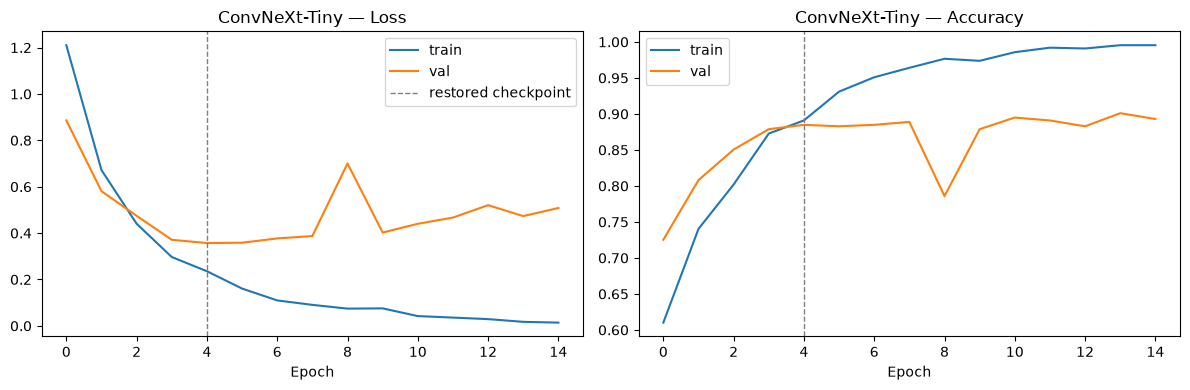

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.886


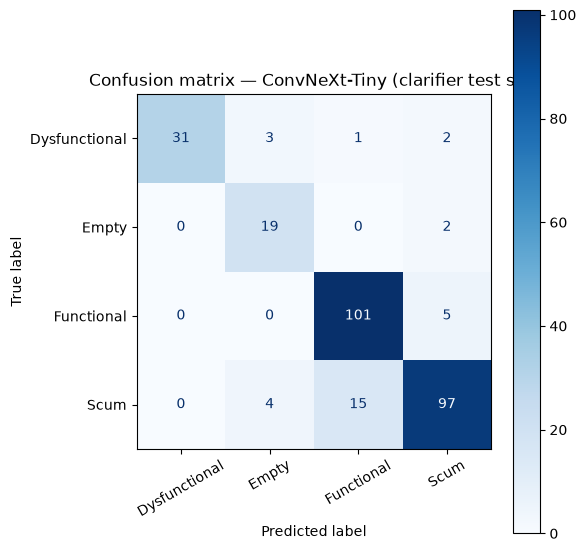

               precision    recall  f1-score   support

Dysfunctional      1.000     0.838     0.912        37
        Empty      0.731     0.905     0.809        21
   Functional      0.863     0.953     0.906       106
         Scum      0.915     0.836     0.874       116

     accuracy                          0.886       280
    macro avg      0.877     0.883     0.875       280
 weighted avg      0.893     0.886     0.886       280



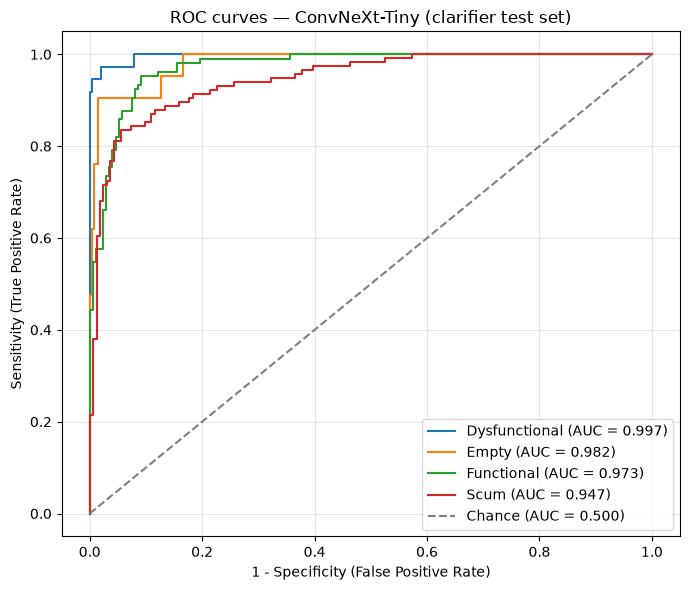

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.997
  Empty          : 0.982
  Functional     : 0.973
  Scum           : 0.947

Mean AUC (over 4/4 classes with test examples): 0.975


(np.float64(0.8857142857142857),
 {'Dysfunctional': 0.9972194416638861,
  'Empty': 0.9821658393086965,
  'Functional': 0.9729993493819128,
  'Scum': 0.9468566021867115})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/clarifier_noaug/results_clarifier_convnext_tiny_stratified.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
